In [1]:
import tensorflow as tf
import keras
from keras import Input, Model 
from keras.layers import Dense, Flatten, Resizing

from keras.applications import vgg16, resnet50

from keras.datasets import cifar10



In [3]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
         'dog', 'frog', 'horse', 'ship', 'truck']
INPUT_SHAPE = (32, 32, 3)


In [5]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 106s 1us/step


# Transfert learning

>Le principe du *transfert learning* consiste à reprendre des réseaux déjà entraînés sur d'autres jeux de données afin de tranférer leur "apprentissage" à de nouveaux problèmes.
>
>En général, on entraîne des architectures qui ont déjà fait leur preuve sur de gros jeux de données très généralistes(*e.g.* [Coco](https://cocodataset.org/#home), [Imagenet](https://image-net.org/), *etc.*).
>
>L'objectif est d'utiliser les convolutions déjà entraînées afin d'extraire les features d'un jeu de donnée. Ceci a pour conséquence de radicalement réduire les temps d'entraînement puisqu'il n'y a plus le besoin d'entraîner la partie convolutive de nos CNN.

>Comment s'y prendre ?
>
>Il faut d'abord charger le modèle en prenant soin de fixer les paramètres comme suit:
>- include_top: permet de ne garder que la partie convolutive de VGG16. Dans notre cas, le *top* contient en fait les couches de sorties prévues pour traiter ImageNet ayant 1000 classes or nous n'avons que 10 classes en sortie.
>
>- input_shape: permet de definir la shape d'entrée, nous avons (32, 32, 3) mais par défaut VGG16 requiert des images de (224, 224, 3) et d'ailleurs a été entraîné avec cette shape. Nous y reviendrons.
>
>- weights: designe les poids pré-entraînés que l'on souhaite charger. Ici, ceux d'ImageNet.
>
>Il ne faut pas oublier de geler les couches de la partie permettant d'extraire les features (*i.e.* éviter de les réentraîner).
```py
INPUT_SHAPE = (32, 32, 3)

extractor = vgg16.VGG16(include_top=False, input_shape=INPUT_SHAPE, weights='imagenet')
extractor.trainable = False
```

>Ensuite, nous construisons notre modèle comme suit:
```py
inputs = Input(INPUT_SHAPE)

x = vgg16.preprocess_input(inputs)
x = extractor(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)

x = Dense(10, activation='softmax')(x)

model = Model(inputs, x)
```
>A noter qu'avant d'envoyer nos images dans notre extracteur, nous devons les faire passer par une fonction de preprocessing. Chaque architecture a sa propre fonction de preprocessing.



In [7]:
extractor = vgg16.VGG16(include_top=False, input_shape=INPUT_SHAPE, weights='imagenet')
extractor.trainable = False

inputs = Input(INPUT_SHAPE)

x = vgg16.preprocess_input(inputs)
x = extractor(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)

x = Dense(10, activation='softmax')(x)

model = Model(inputs, x)

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=1, batch_size=4*1024, validation_split=.2)


10/10 ━━━━━━━━━━━━━━━━━━━━ 169s 17s/step - accuracy: 0.2026 - loss: 13.0595 - val_accuracy: 0.4740 - val_loss: 5.4791


In [8]:
model.fit(X_train, y_train, epochs=1, batch_size=2*1024, validation_split=.2)


20/20 ━━━━━━━━━━━━━━━━━━━━ 165s 8s/step - accuracy: 0.5098 - loss: 4.6520 - val_accuracy: 0.5448 - val_loss: 3.0623


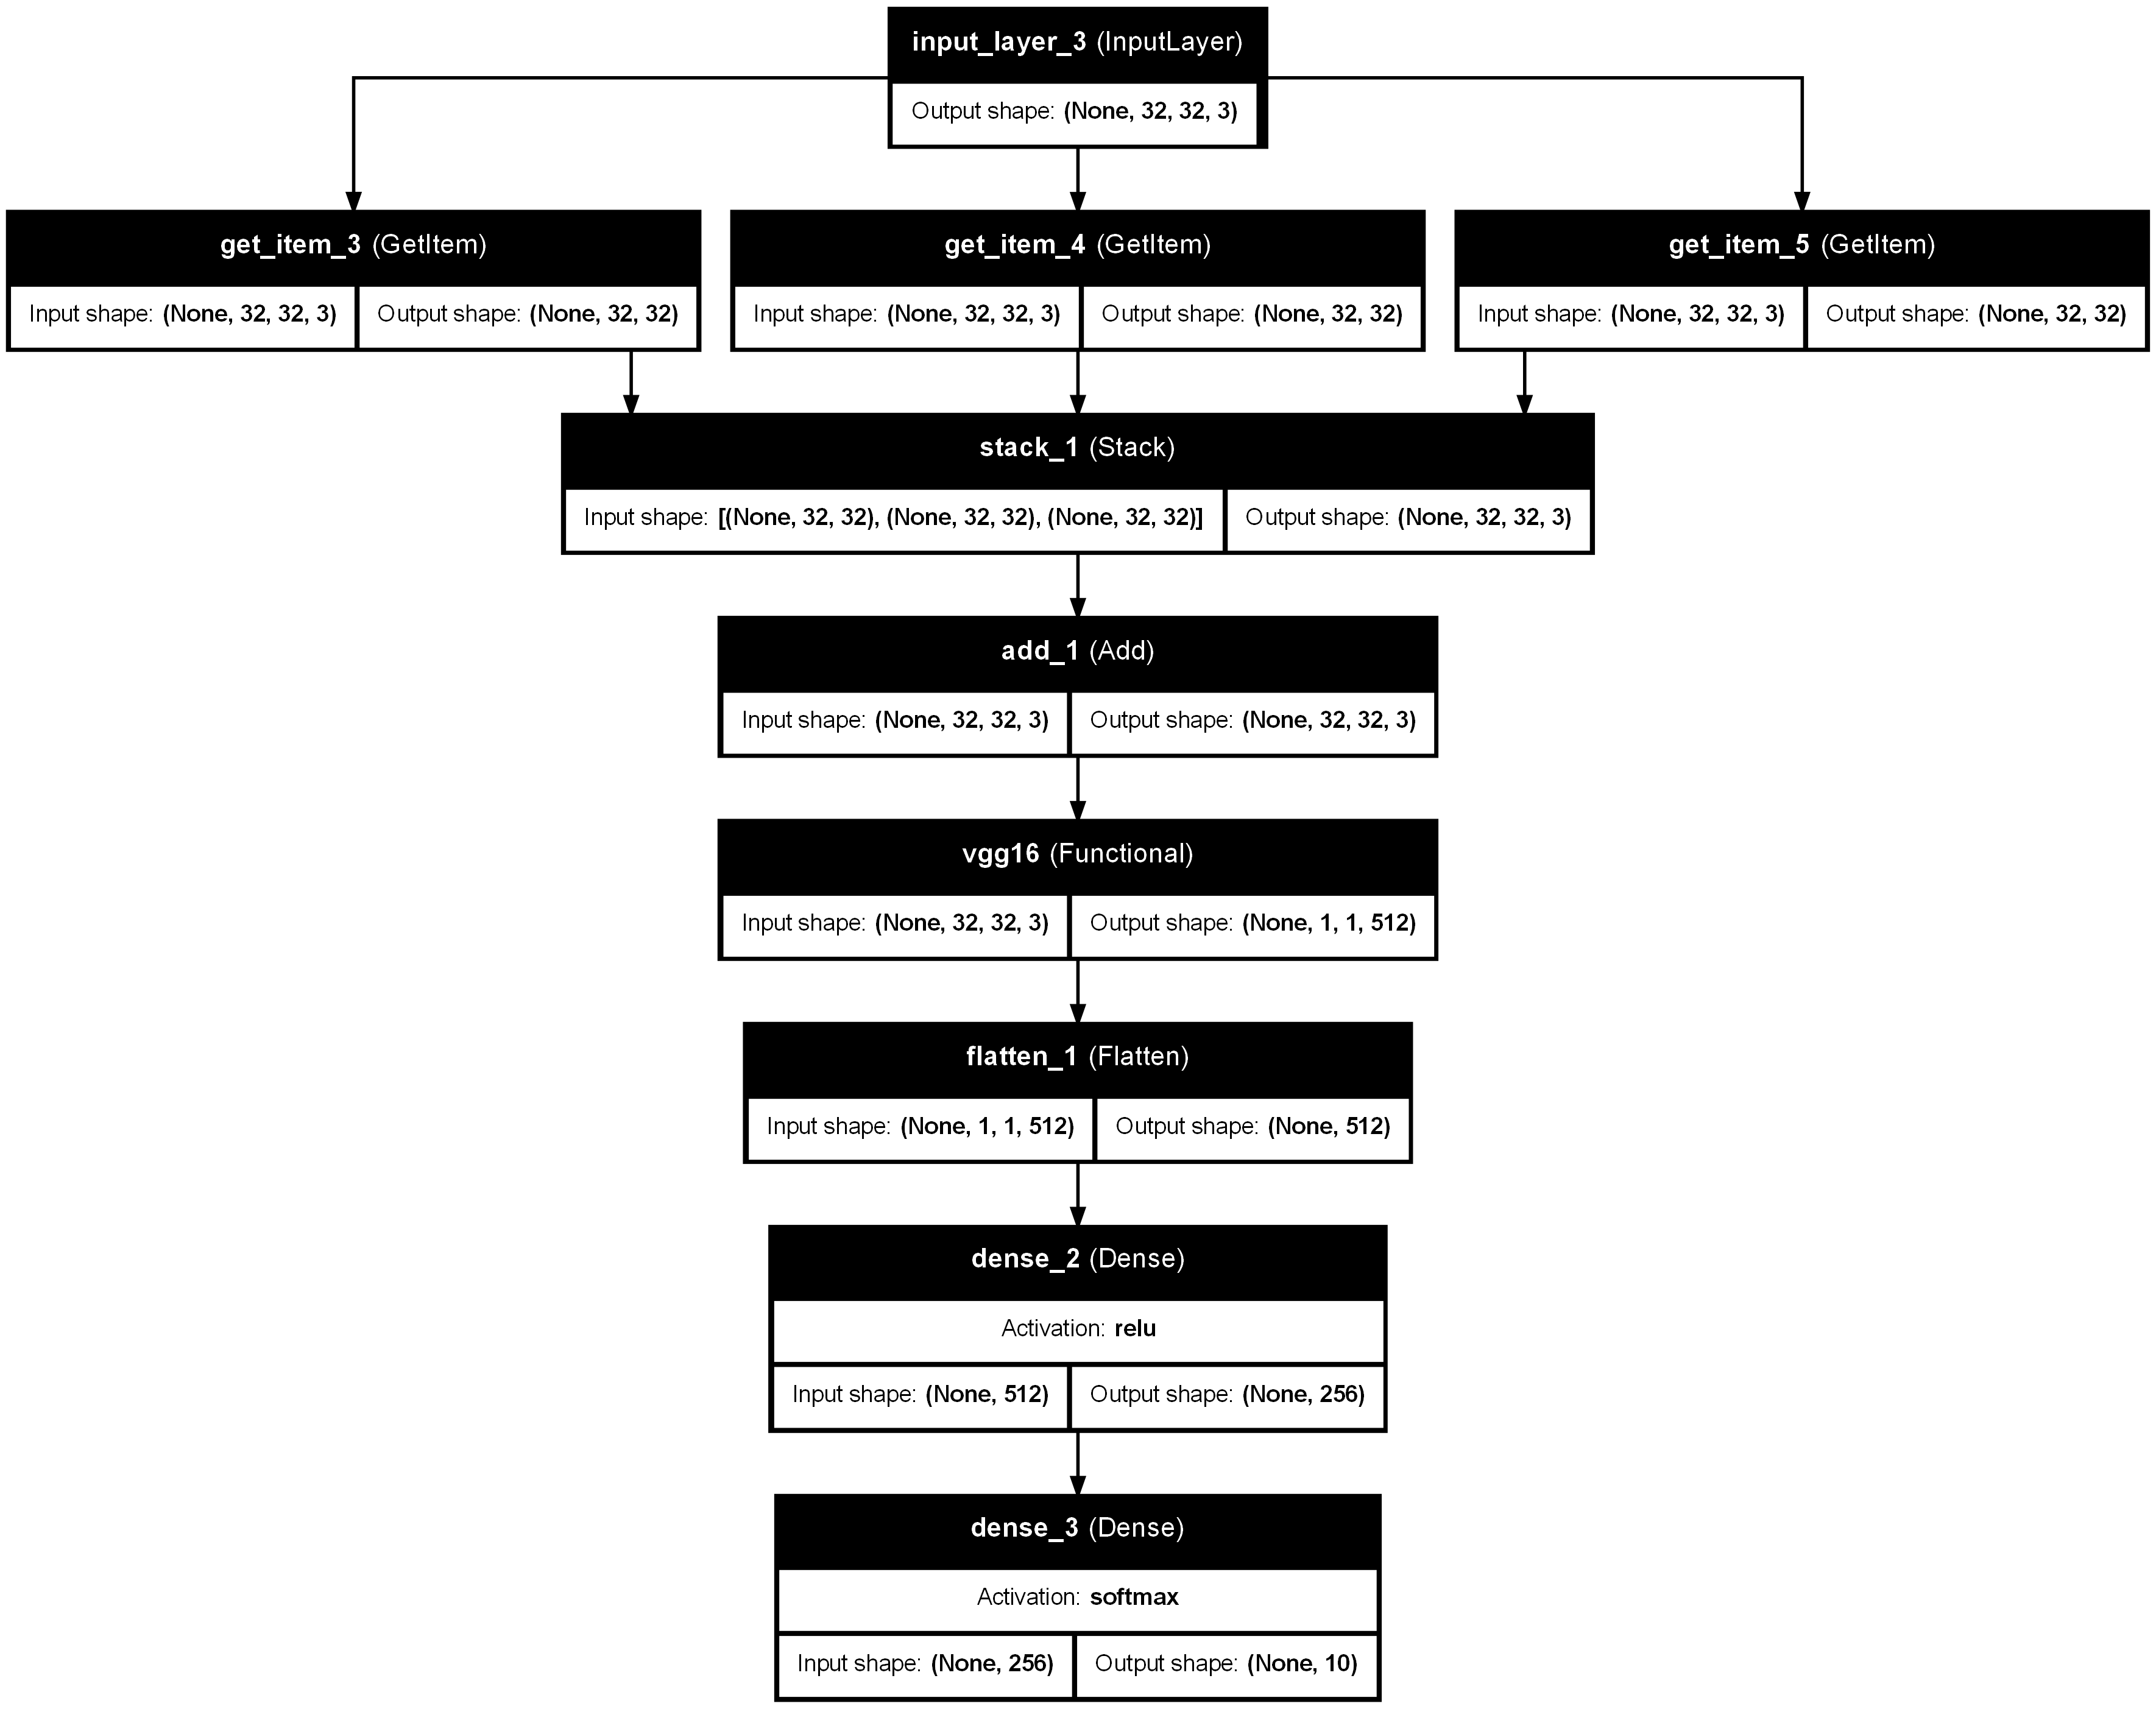

In [10]:
keras.utils.plot_model(
    model = model,
    show_layer_activations=True,
    show_layer_names=True,
    show_shapes=True
)

In [11]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 32, 32)    │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 32, 32)    │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 32, 32)    │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 32, 32, 3) │          0 │ get_item_3[0][0], │
│                     │                   │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32, 3) │          0 │ stack_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 1, 1, 512) │ 14,714,688 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 512)       │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │      2,570 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,116,384 (57.66 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 267,798 (1.02 MB)